In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
DATA_PATH = r'C:\Users\manur\OneDrive\Desktop\DSGP\Weather-Prediction-and-Crop-Recommendation-System-\Data\df_with_scenario.csv'
df = pd.read_csv(DATA_PATH)

ENV_COLS = [
    'temperature', 'rainfall', 'sunshine_hours',
    'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'texture_code'
]

rounded = df[ENV_COLS].round(2)
df['scenario_id'] = pd.util.hash_pandas_object(rounded, index=False).astype('int64')

In [3]:
# Prepare features and target
y = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0}).astype(int)
DROP_COLS = ['suitability_class', 'suitability', 'texture', 'rooting_depth_m']
X = df.drop(columns=DROP_COLS)
groups = df['scenario_id']

categorical_cols = ['crop']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

In [4]:
# Train/test split by scenario
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train scenarios: {g_train.nunique()}, Test scenarios: {g_test.nunique()}')

Train: (1680, 11), Test: (420, 11)
Train scenarios: 1680, Test scenarios: 420


In [5]:
# Define preprocessor
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

In [ ]:

baseline_pipe = Pipeline([
    ('preprocess', clone(preprocessor)),
    ('model', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
])

baseline_pipe.fit(X_train, y_train)

baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_proba >= 0.5).astype(int)

baseline_roc = roc_auc_score(y_test, baseline_proba)
baseline_pr = average_precision_score(y_test, baseline_proba)

print("=== Baseline XGBoost ===")
print(f"ROC-AUC: {baseline_roc:.4f}")
print(f"PR-AUC:  {baseline_pr:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))
print("\nClassification Report:")
print(classification_report(y_test, baseline_pred, digits=3))

=== Baseline XGBoost ===
ROC-AUC: 0.9263
PR-AUC:  0.9512

Confusion Matrix:
[[137  37]
 [ 29 217]]

Classification Report:
              precision    recall  f1-score   support

           0      0.825     0.787     0.806       174
           1      0.854     0.882     0.868       246

    accuracy                          0.843       420
   macro avg      0.840     0.835     0.837       420
weighted avg      0.842     0.843     0.842       420



In [ ]:
# Hyperparameter tuning
pipe = Pipeline(steps=[('preprocess', preprocessor),
                       ('model', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))])

param_grid = {
    'model__n_estimators': [200, 400, 600],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 4, 5, 6],
    'model__subsample': [0.7, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.9, 1.0],
    'model__reg_alpha': [0, 0.1],
    'model__reg_lambda': [1]
}

cv = GroupKFold(n_splits=5)
gs = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train, groups=g_train)

print("Best parameters:")
print(gs.best_params_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best parameters:
{'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__reg_alpha': 0, 'model__reg_lambda': 1, 'model__subsample': 0.9}


In [8]:
# Evaluate tuned model on test set
best_model = gs.best_estimator_
tuned_proba = best_model.predict_proba(X_test)[:, 1]
tuned_pred = (tuned_proba >= 0.5).astype(int)

tuned_roc = roc_auc_score(y_test, tuned_proba)
tuned_pr = average_precision_score(y_test, tuned_proba)

print("=== Tuned XGBoost ===")
print(f"ROC-AUC: {tuned_roc:.4f}")
print(f"PR-AUC:  {tuned_pr:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))
print("\nClassification Report:")
print(classification_report(y_test, tuned_pred, digits=3))

=== Tuned XGBoost ===
ROC-AUC: 0.9393
PR-AUC:  0.9593

Confusion Matrix:
[[143  31]
 [ 31 215]]

Classification Report:
              precision    recall  f1-score   support

           0      0.822     0.822     0.822       174
           1      0.874     0.874     0.874       246

    accuracy                          0.852       420
   macro avg      0.848     0.848     0.848       420
weighted avg      0.852     0.852     0.852       420



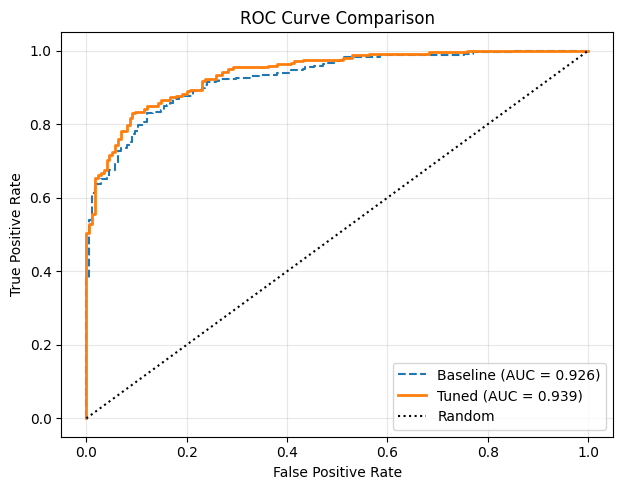

In [ ]:
# ROC curves
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_proba)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {baseline_roc:.3f})', linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC = {tuned_roc:.3f})', linewidth=2)
plt.plot([0,1],[0,1], 'k:', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

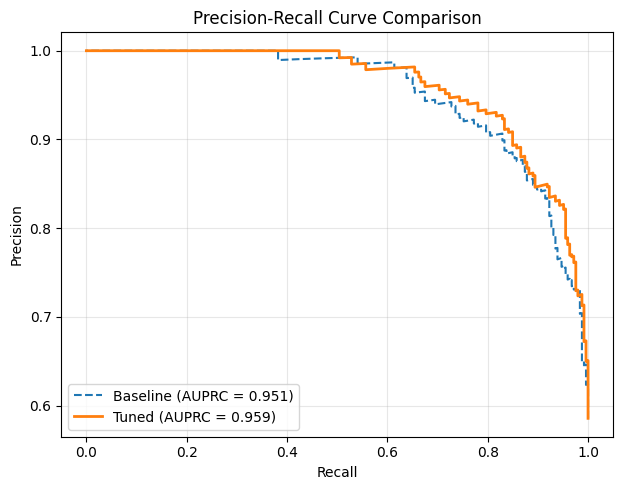

In [10]:
# PR curves
prec_base, rec_base, _ = precision_recall_curve(y_test, baseline_proba)
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, tuned_proba)
pr_auc_base = auc(rec_base, prec_base)
pr_auc_tuned = auc(rec_tuned, prec_tuned)

plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
plt.plot(rec_base, prec_base, label=f'Baseline (AUPRC = {pr_auc_base:.3f})', linestyle='--')
plt.plot(rec_tuned, prec_tuned, label=f'Tuned (AUPRC = {pr_auc_tuned:.3f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

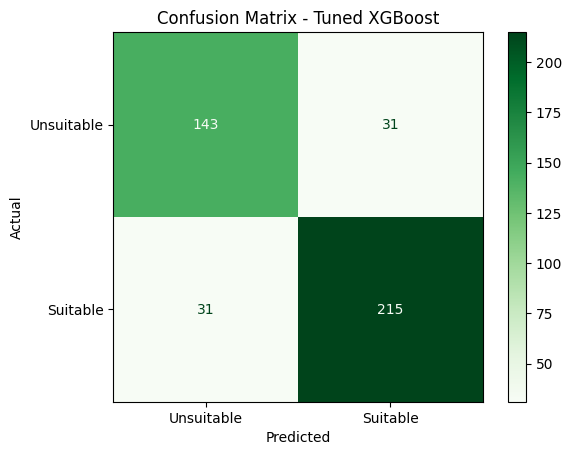

In [11]:
# Confusion Matrix
tuned_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, tuned_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unsuitable', 'Suitable'])
disp.plot(cmap='Greens', values_format='d')
disp.ax_.set_xlabel('Predicted')
disp.ax_.set_ylabel('Actual')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()

In [13]:
joblib.dump(baseline_pipe, 'baseline_xgb.pkl')
joblib.dump(best_model, 'tuned_xgb.pkl')

['tuned_xgb.pkl']